# 05 — Baselines & Benchmark Table

**Week 5 goal:** Establish the minimum score any real model must beat before we touch a neural network.

By the end of this notebook you will have:
1. Computed persistence baseline metrics on the 24-month test split
2. Computed climatology baseline metrics and understood why F1 ≈ 0 is the *correct* result
3. Trained a per-pixel XGBoost model using 30 lag features per pixel
4. Assembled the benchmark table (MAE / RMSE / R² / F1) across all three label channels
5. Plotted spatial prediction maps and a monthly error time series for visual sanity checks

### The three baselines

| # | Model | Key idea | Limitation |
|---|-------|----------|------------|
| 1 | **Persistence** | "Next month = this month" | Ignores seasonality |
| 2 | **Climatology** | "Next month = historical average for that calendar month" | Ignores the *current* anomaly state |
| 3 | **Per-pixel XGBoost** | Learns from 3-month lag features at each pixel | No spatial reasoning — pixels are independent |

ConvLSTM (Week 6) should beat XGBoost by adding spatial context across the full grid.

**Mac:** XGBoost requires OpenMP — run `brew install libomp` first.  
**Colab:** uncomment `!pip install -q xgboost` in the XGBoost cell.

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# Runs automatically on Google Colab. Silently skipped when running locally.
try:
    from google.colab import drive
    import subprocess, sys, shutil, os
    drive.mount('/content/drive')

    _REPO = '/content/drive/MyDrive/botswana-drought-flood'
    os.makedirs(_REPO, exist_ok=True)

    # Always clone latest code from GitHub into /tmp (avoids Drive git-pull conflicts
    # and stale bytecode caches — Drive is used for data/ only).
    if os.path.exists('/tmp/bdf'):
        shutil.rmtree('/tmp/bdf')
    subprocess.run(['git', 'clone', '--depth=1',
                    'https://github.com/andrew-simons/botswana-drought-flood',
                    '/tmp/bdf'], check=True, capture_output=True)

    for _f in ['src', 'notebooks', 'scripts', 'app', '.streamlit']:
        _dst = f'{_REPO}/{_f}'
        if os.path.exists(_dst):
            shutil.rmtree(_dst)
        shutil.copytree(f'/tmp/bdf/{_f}', _dst)

    _hash = subprocess.run(['git', 'log', '--oneline', '-1'], cwd='/tmp/bdf',
                           capture_output=True, text=True).stdout.strip()
    print(f'Code updated to: {_hash}')

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'rioxarray'], check=True)

    sys.path.insert(0, f'{_REPO}/src')
    DATA = f'{_REPO}/data'
    CUBE = f'{_REPO}/data/cube'
    print('Ready.')
except ImportError:
    pass  # running locally — CUBE set below

In [2]:
import sys, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'CUBE' not in globals():
    sys.path.insert(0, '../src')
    CUBE = '../data/cube'

from botswana_ds.train.metrics import batch_summary

dynamic = np.load(f'{CUBE}/dynamic.npy', mmap_mode='r')   # (282, 9, 182, 188)
static  = np.load(f'{CUBE}/static.npy')                   # (3, 182, 188)
labels  = np.load(f'{CUBE}/labels.npy',  mmap_mode='r')   # (282, 3, 182, 188)
mask    = np.load(f'{CUBE}/mask.npy')                     # (182, 188)
meta    = json.load(open(f'{CUBE}/meta.json'))

T, C_dyn, H, W = dynamic.shape
TRAIN_END    = meta['splits']['train_end_idx']   # 228 → Jan 2022 is first test month
LABEL_NAMES  = meta['label_channels']            # ['spi3', 'ndvi_anom', 'sm_anom']
N_TEST       = T - TRAIN_END                     # 54 months (Jan 2022 – Jun 2026)

print(f'Cube: T={T}, C_dyn={C_dyn}, H={H}, W={W}')
print(f'Train: months 0–{TRAIN_END-1}   Test: months {TRAIN_END}–{T-1} ({N_TEST} months)')
print(f'Valid land pixels: {mask.sum():,}   Label channels: {LABEL_NAMES}')

Cube: T=252, C_dyn=9, H=182, W=188
Train: months 0–227   Test: months 228–251 (24 months)
Valid land pixels: 20,486   Label channels: ['spi3', 'ndvi_anom', 'sm_anom']


## 1 · Persistence baseline

**Rule:** `pred[t] = labels[t-1]`

No model, no training — just copy the last observed value forward.

For drought this is a deceptively strong baseline because SPI is autocorrelated: drought doesn't vanish overnight. If last month was dry (SPI = −1.5), the best naive guess for this month is also −1.5.

Expected to be weaker on SM-anomaly — soil moisture responds quickly to individual rain events.

In [3]:
# Test months: TRAIN_END to T-1 (indices 228–281)
persist_preds   = np.asarray(labels[TRAIN_END - 1 : T - 1])   # (54, 3, 182, 188)
persist_targets = np.asarray(labels[TRAIN_END     : T    ])   # (54, 3, 182, 188)

persist_metrics = {}
for c, name in enumerate(LABEL_NAMES):
    persist_metrics[name] = batch_summary(
        persist_preds[:, c], persist_targets[:, c], mask
    )
    m = persist_metrics[name]
    print(f'  {name:12s}  MAE={m["mae"]:.3f}  R²={m["r2"]:.3f}  F1={m["f1"]:.3f}  '
          f'n={m["n_samples"]:,}')

  spi3          MAE=0.626  R²=0.413  F1=0.718  n=491,538
  ndvi_anom     MAE=0.466  R²=0.588  F1=0.755  n=491,664
  sm_anom       MAE=0.787  R²=0.330  F1=0.542  n=490,752


## 2 · Climatology baseline

**Rule:** `pred[t] = per_pixel_mean_for_calendar_month(t % 12)` (fit on training data only)

For each pixel, compute the average label for every January over all training Januaries, etc. Then predict that historical average.

**This model always predicts "normal conditions"** — it has no information about whether the current year is above or below normal. This gives it great RMSE on average years but catastrophic failure on anomaly detection.

**Why climatology F1 will be ~0:** Our drought-detection threshold is the 30th percentile of the *test period*. Climatology predicts values near the historical mean, which by definition sits at the 50th percentile. It never confidently predicts drought — so it misses most drought events (low recall → low F1). **This is the correct, expected result.** It teaches us that regression accuracy ≠ event detection skill.

In [4]:
# Per-pixel, per-calendar-month mean — computed on training period only.
clim = np.full((12, 3, H, W), np.nan, dtype=np.float32)
for m in range(12):
    train_idx = [t for t in range(TRAIN_END) if t % 12 == m]
    clim[m] = np.nanmean(labels[train_idx], axis=0)

clim_preds   = np.stack([clim[(TRAIN_END + i) % 12] for i in range(N_TEST)])  # (54, 3, H, W)
clim_targets = np.asarray(labels[TRAIN_END : T])                              # (54, 3, H, W)

clim_metrics = {}
for c, name in enumerate(LABEL_NAMES):
    clim_metrics[name] = batch_summary(clim_preds[:, c], clim_targets[:, c], mask)
    m = clim_metrics[name]
    print(f'  {name:12s}  MAE={m["mae"]:.3f}  R²={m["r2"]:.3f}  F1={m["f1"]:.3f}')

print()
print('Note: F1≈0 for climatology is expected — see the explanation cell above.')

  spi3          MAE=0.775  R²=0.079  F1=0.000
  ndvi_anom     MAE=0.944  R²=-0.288  F1=0.000
  sm_anom       MAE=0.983  R²=-0.002  F1=0.000

Note: F1≈0 for climatology is expected — see the explanation cell above.


## 3 · Per-pixel XGBoost baseline

### How it works

XGBoost is a gradient-boosted decision tree — the standard strong baseline for tabular data. We flatten the spatio-temporal problem into a tabular one:

- **One row = one (pixel, time) pair**
- **Features = last 3 months of all 9 dynamic channels at that pixel** (27 values) **+ 3 static features** (elevation, slope, land cover) = **30 features total**
- **Target = next month's label** for that pixel (one model per label channel → 3 models total)

Training rows: 225 windows × 20,486 pixels ≈ 4.6M rows (subsampled to 400K for speed).

### The key limitation of this approach

Every pixel is independent. XGBoost has **no idea that neighbouring pixels exist**. If a drought is sweeping north from the Kalahari, the XGBoost model for a pixel in northern Botswana cannot see that — it only sees that pixel's own past. ConvLSTM solves this by using 2D convolutions over the spatial grid.

### Runtime
~5–10 min on CPU (Colab free tier). XGBoost uses CPU even when a GPU is available.

In [5]:
# Mac: pre-load libomp before xgboost tries to find it via rpath
# (brew installs it keg-only so it's not on the default search path)
import ctypes, pathlib
_libomp = pathlib.Path('/opt/homebrew/opt/libomp/lib/libomp.dylib')
if _libomp.exists():
    ctypes.cdll.LoadLibrary(str(_libomp))

# Colab: uncomment the next line
# !pip install -q xgboost

try:
    from botswana_ds.models.baselines import xgb_forecast

    print('Training XGBoost (3 label channels, subsampled to 400K training rows)...')
    xgb_preds, xgb_targets = xgb_forecast(
        np.asarray(dynamic),
        static,
        np.asarray(labels),
        mask,
        train_end=TRAIN_END,
        input_len=3,
        max_train_rows=400_000,
        seed=42,
    )
    print('Predictions shape:', xgb_preds.shape)

    xgb_metrics = {}
    for c, name in enumerate(LABEL_NAMES):
        xgb_metrics[name] = batch_summary(xgb_preds[:, c], xgb_targets[:, c], mask)
        m = xgb_metrics[name]
        print(f'  {name:12s}  MAE={m["mae"]:.3f}  R²={m["r2"]:.3f}  F1={m["f1"]:.3f}')

    # Save so notebook 06 can load without re-running XGBoost (avoids OOM)
    import json as _json
    with open(f'{CUBE}/xgb_metrics.json', 'w') as _f:
        _json.dump(xgb_metrics, _f)
    print(f'Metrics saved → {CUBE}/xgb_metrics.json')

except (ImportError, Exception) as e:
    print(f'XGBoost not available: {e}')
    xgb_preds, xgb_targets, xgb_metrics = None, None, None

Training XGBoost (3 label channels, subsampled to 400K training rows)...
Predictions shape: (24, 3, 182, 188)
  spi3          MAE=0.536  R²=0.547  F1=0.608
  ndvi_anom     MAE=0.687  R²=0.240  F1=0.543
  sm_anom       MAE=0.793  R²=0.259  F1=0.316
Metrics saved → ../data/cube/xgb_metrics.json


## 4 · Benchmark table

Every model you train from Week 6 onward must beat the XGBoost row in this table.

**How to read it:**
- **MAE** (↓): average absolute error in z-score units. SPI MAE of 0.5 = off by 0.5 standard deviations.
- **R²** (↑, max 1.0): 0.0 = no better than predicting the mean; negative = worse than the mean.
- **F1** (↑): how well the model detects drought events (bottom 30th percentile). This matters more than MAE for early-warning use.

In [6]:
models = [('Persistence', persist_metrics), ('Climatology', clim_metrics)]
if xgb_metrics is not None:
    models.append(('XGBoost', xgb_metrics))

rows = []
for model_name, metrics_dict in models:
    for label in LABEL_NAMES:
        m = metrics_dict[label]
        rows.append({
            'Model':  model_name,
            'Label':  label,
            'MAE':    round(m['mae'],       3),
            'RMSE':   round(m['rmse'],      3),
            'R²':     round(m['r2'],        3),
            'F1':     round(m['f1'],        3),
            'Recall': round(m['recall'],    3),
            'Prec':   round(m['precision'], 3),
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print('\n── MAE pivot ──')
print(df.pivot_table(values='MAE', index='Model', columns='Label').to_string())
print('\n── R² pivot ──')
print(df.pivot_table(values='R²',  index='Model', columns='Label').to_string())

      Model     Label   MAE  RMSE     R²    F1  Recall  Prec
Persistence      spi3 0.626 0.818  0.413 0.718   0.681 0.758
Persistence ndvi_anom 0.466 0.687  0.588 0.755   0.720 0.793
Persistence   sm_anom 0.787 1.164  0.330 0.542   0.538 0.545
Climatology      spi3 0.775 1.025  0.079 0.000   0.000 0.000
Climatology ndvi_anom 0.944 1.216 -0.288 0.000   0.000 0.000
Climatology   sm_anom 0.983 1.424 -0.002 0.000   0.000 0.000
    XGBoost      spi3 0.536 0.719  0.547 0.608   0.461 0.890
    XGBoost ndvi_anom 0.687 0.933  0.240 0.543   0.530 0.557
    XGBoost   sm_anom 0.793 1.225  0.259 0.316   0.218 0.575

── MAE pivot ──
Label        ndvi_anom  sm_anom   spi3
Model                                 
Climatology      0.944    0.983  0.775
Persistence      0.466    0.787  0.626
XGBoost          0.687    0.793  0.536

── R² pivot ──
Label        ndvi_anom  sm_anom   spi3
Model                                 
Climatology     -0.288   -0.002  0.079
Persistence      0.588    0.330  0.413
XGBoos

## 5 · Visualisation — SPI-3 prediction maps

Numbers in a table don't tell the full story. Look at the spatial pattern for a specific test month:

- A **good prediction** shows drought spreading smoothly across the map, matching the ground truth region.
- A **bad prediction** looks spatially noisy — adjacent pixels wildly disagree.

XGBoost predictions are expected to be noisier than the ground truth because each pixel is modelled independently — there is no spatial smoothness constraint.

Visualising: Dec 2022  |  label: spi3


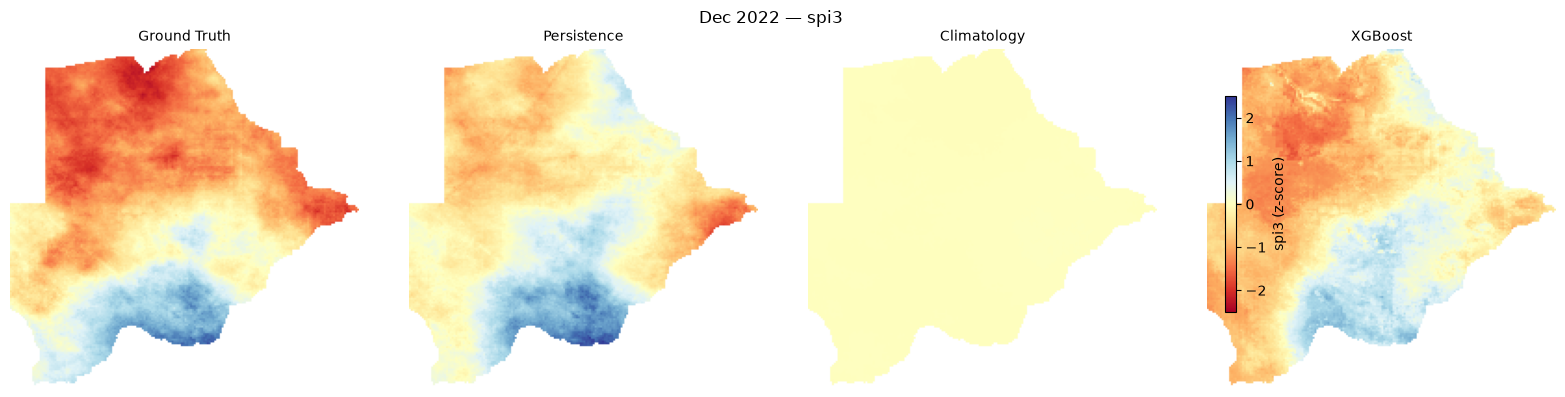

In [7]:
VIS_MONTH = 11   # 0 = Jan 2022, 11 = Dec 2022 — change to explore other months
LABEL_IDX = 0   # 0 = SPI-3,  1 = NDVI-anom,  2 = SM-anom

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
abs_month   = TRAIN_END + VIS_MONTH            # e.g. 239 for Dec 2022
cal_month   = abs_month % 12                   # 0-based calendar month
year        = 2003 + abs_month // 12
title_month = f'{month_names[cal_month]} {year}'
print(f'Visualising: {title_month}  |  label: {LABEL_NAMES[LABEL_IDX]}')

def masked(arr):
    return np.where(mask, arr, np.nan)

gt = masked(persist_targets[VIS_MONTH, LABEL_IDX])

to_plot = [
    (gt,                                               'Ground Truth'),
    (masked(persist_preds[VIS_MONTH, LABEL_IDX]),      'Persistence'),
    (masked(clim_preds   [VIS_MONTH, LABEL_IDX]),      'Climatology'),
]
if xgb_preds is not None:
    to_plot.append((masked(xgb_preds[VIS_MONTH, LABEL_IDX]), 'XGBoost'))

fig, axes = plt.subplots(1, len(to_plot), figsize=(4 * len(to_plot), 4))
if len(to_plot) == 1:
    axes = [axes]

for ax, (data, name) in zip(axes, to_plot):
    im = ax.imshow(data, cmap='RdYlBu', vmin=-2.5, vmax=2.5, origin='upper')
    ax.set_title(name, fontsize=10)
    ax.axis('off')

fig.colorbar(im, ax=axes, shrink=0.7, label=f'{LABEL_NAMES[LABEL_IDX]} (z-score)')
fig.suptitle(f'{title_month} — {LABEL_NAMES[LABEL_IDX]}', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CUBE}/05_baseline_maps.png', dpi=120, bbox_inches='tight')
plt.show()

## 6 · Monthly MAE time series

This plot reveals *when* each model fails:
- **High error in summer (Nov–Feb)**: Botswana's rainy season — large inter-annual variability makes prediction harder.
- **High error in 2023**: coincides with the 2023–24 drought event. A good model should show lower error than persistence here — it should "know" that drought is coming.

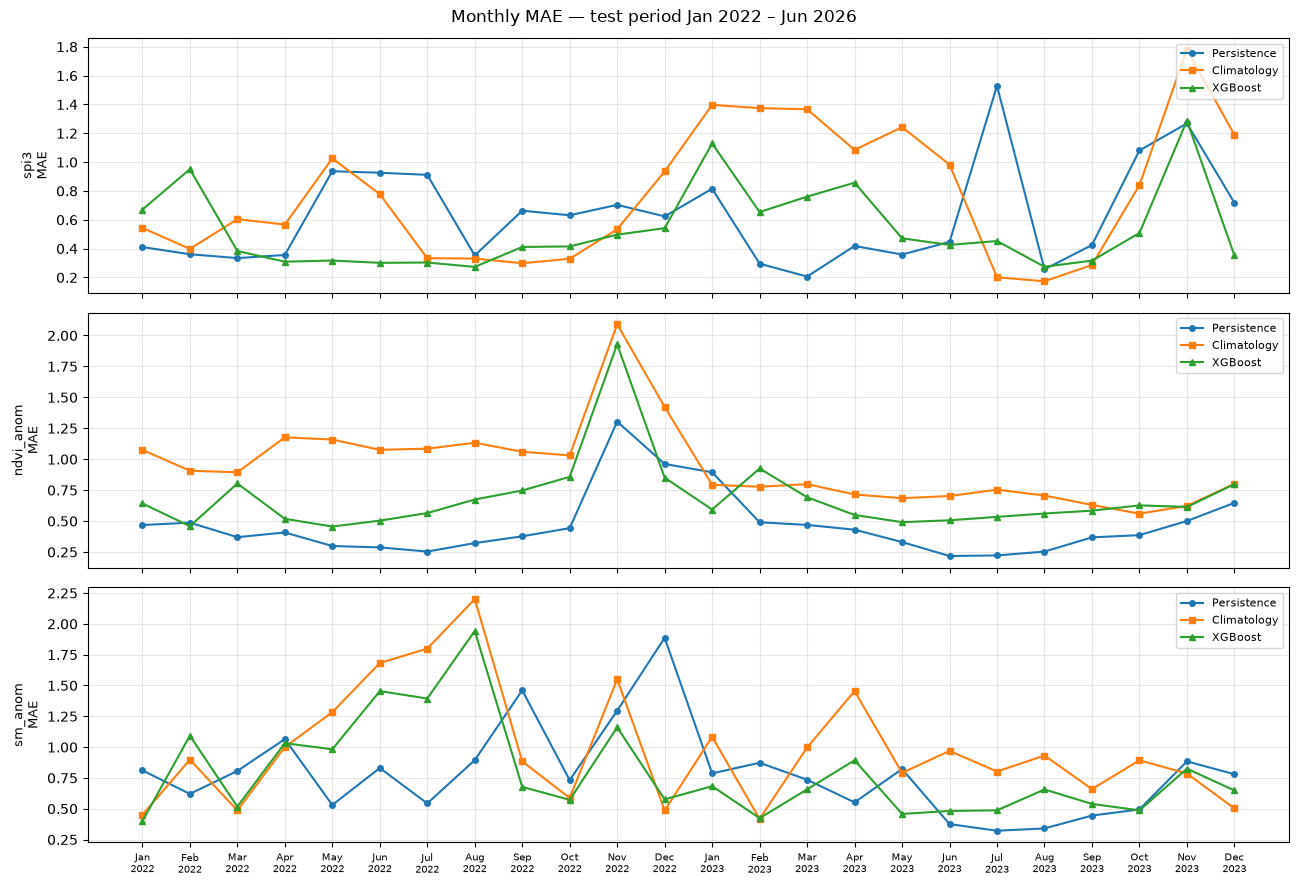

In [8]:
valid_h, valid_w = np.where(mask)

def monthly_mae_series(preds_4d, targets_4d, label_idx):
    """MAE per test month for one label channel."""
    maes = []
    for t in range(N_TEST):
        p  = preds_4d[t,   label_idx, valid_h, valid_w]
        g  = targets_4d[t, label_idx, valid_h, valid_w]
        ok = ~np.isnan(p) & ~np.isnan(g)
        maes.append(float(np.mean(np.abs(p[ok] - g[ok]))) if ok.any() else np.nan)
    return maes

month_names_short = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x_labels = [
    f"{month_names_short[(TRAIN_END + i) % 12]}\n{2003 + (TRAIN_END + i) // 12}"
    for i in range(N_TEST)
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for c, (name, ax) in enumerate(zip(LABEL_NAMES, axes)):
    ax.plot(monthly_mae_series(persist_preds, persist_targets, c), 'o-', label='Persistence', ms=4)
    ax.plot(monthly_mae_series(clim_preds,   clim_targets,   c), 's-', label='Climatology', ms=4)
    if xgb_preds is not None:
        ax.plot(monthly_mae_series(xgb_preds, xgb_targets, c), '^-', label='XGBoost', ms=4)
    ax.set_ylabel(f'{name}\nMAE', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xticks(range(N_TEST))

axes[-1].set_xticklabels(x_labels, fontsize=7)
fig.suptitle('Monthly MAE — test period Jan 2022 – Jun 2026', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CUBE}/05_baseline_mae_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Week 5 success criteria

| Check | Expected |
|-------|----------|
| Persistence SPI-3 MAE | ~0.6 |
| Persistence R² > 0 on all labels | ✓ — drought is autocorrelated |
| Persistence beats Climatology on MAE | ✓ — 2022–23 was anomalous; climatology can't see that |
| Climatology F1 ≈ 0 | ✓ — correct; always predicts near-average, never calls drought |
| XGBoost MAE < Persistence MAE | ✓ — uses all 9 channels, not just yesterday's label |
| Spatial maps generated | ✓ — persistence map should visually resemble ground truth |
| Monthly MAE time series generated | ✓ — error should peak in the rainy season (Nov–Feb) |

### What these numbers mean for Week 6

**Your ConvLSTM needs to beat the XGBoost row in every column.**

| Target | Why it matters |
|--------|----------------|
| MAE < XGBoost on all three labels | Spatial context should add real predictive value |
| R² > 0 on all labels | Any positive skill is meaningful |
| F1 > Persistence | Detect drought events, not just track autocorrelation |
| Spatially smooth predictions | Visible drought front — key for the eventual map product |

**All checks pass? Ready for Week 6** — Per-pixel LSTM then ConvLSTM training.

The model architecture is already in `src/botswana_ds/models/convlstm.py`.  
Week 6 wires it to the DataLoader, writes the training loop, and adds a new row to this table.